# Fraud Detection - PaySim Dataset

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import xgboost as xgb
from imblearn.over_sampling import SMOTE
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded")

Libraries loaded


## 1. Load Data

In [2]:
df = pd.read_csv('PS_20174392719_1491204439457_log.csv')
print(f"Loaded {len(df):,} transactions")
print(f"Fraud rate: {df['isFraud'].mean()*100:.2f}%")
df.head()

Loaded 6,362,620 transactions
Fraud rate: 0.13%


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## 2. Filter Data

In [3]:
df = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()
df = df.drop(columns=['step', 'nameOrig', 'nameDest', 'isFlaggedFraud'])
print(f"After filtering: {len(df):,} transactions")
print(f"Fraud rate: {df['isFraud'].mean()*100:.2f}%")

After filtering: 2,770,409 transactions
Fraud rate: 0.30%


## 3. Feature Engineering

In [4]:
df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

le = LabelEncoder()
df['type_encoded'] = le.fit_transform(df['type'])

print("Features created")
df[['amount', 'errorBalanceOrig', 'errorBalanceDest', 'isFraud']].describe()

Features created


,amount,errorBalanceOrig,errorBalanceDest,isFraud
count,2.770409e+06,2.770409e+06,2.770409e+06,2.770409e+06
mean,3.175361e+05,2.859850e+05,-2.864713e+04,2.964544e-03
std,8.877897e+05,8.753230e+05,5.934794e+05,5.436687e-02
min,0.000000e+00,-1.000000e-02,-7.588573e+07,0.000000e+00
25%,8.297354e+04,5.185310e+04,0.000000e+00,0.000000e+00
50%,1.712609e+05,1.435971e+05,0.000000e+00,0.000000e+00
75%,3.067912e+05,2.798912e+05,0.000000e+00,0.000000e+00
max,9.244552e+07,9.244552e+07,1.000000e+07,1.000000e+00


## 4. Prepare Train/Test

In [5]:
X = df[['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 
        'newbalanceDest', 'errorBalanceOrig', 'errorBalanceDest', 'type_encoded']]
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                      random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

Train: 2,216,327 | Test: 554,082


## 5. Handle Imbalanced Data

In [6]:
print(f"Before SMOTE: {y_train.sum():,} fraud, {len(y_train)-y_train.sum():,} legit")

smote = SMOTE(random_state=42, sampling_strategy=0.5)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"After SMOTE: {y_train_resampled.sum():,} fraud, {len(y_train_resampled)-y_train_resampled.sum():,} legit")

Before SMOTE: 6,570 fraud, 2,209,757 legit
After SMOTE: 1,104,878 fraud, 2,209,757 legit


## 6. Train Model

In [7]:
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

print("Training...")
model.fit(X_train_resampled, y_train_resampled)
print("Done")

Training...
Done


## 7. Evaluate

In [8]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

roc_auc = roc_auc_score(y_test, y_proba)
print(f"\nROC-AUC: {roc_auc:.4f}")

Classification Report:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00    552439
       Fraud       0.57      0.99      0.72      1643

    accuracy                           1.00    554082
   macro avg       0.78      1.00      0.86    554082
weighted avg       1.00      1.00      1.00    554082


Confusion Matrix:
[[551185   1254]
 [     9   1634]]

ROC-AUC: 0.9988


## 8. Visualize

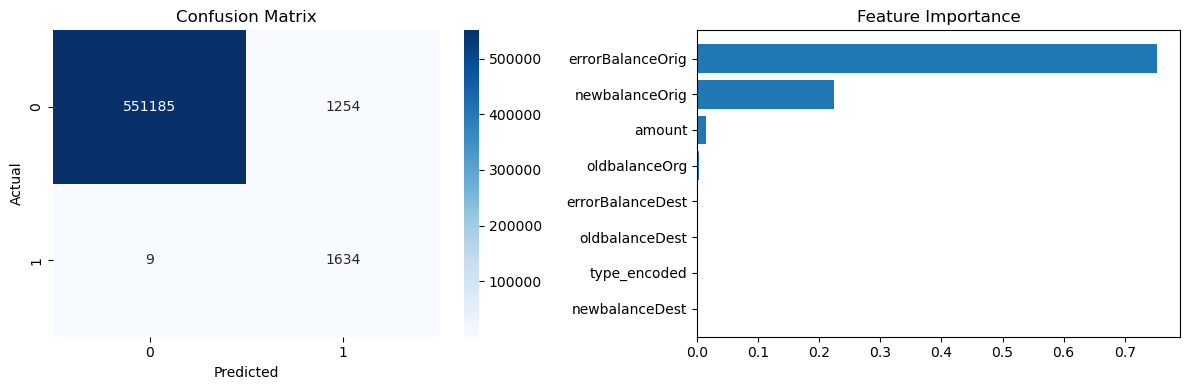

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

axes[1].barh(importance['feature'], importance['importance'])
axes[1].set_title('Feature Importance')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 9. Save Models

In [10]:
joblib.dump(model, 'fraud_detection_model.joblib')
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(le, 'label_encoder_type.joblib')

print("Models saved:")
print("- fraud_detection_model.joblib")
print("- scaler.joblib")
print("- label_encoder_type.joblib")

Models saved:
- fraud_detection_model.joblib
- scaler.joblib
- label_encoder_type.joblib


## 10. Test Prediction

In [11]:
def predict_transaction(transaction):
    error_orig = transaction['newbalanceOrig'] + transaction['amount'] - transaction['oldbalanceOrg']
    error_dest = transaction['oldbalanceDest'] + transaction['amount'] - transaction['newbalanceDest']
    type_enc = le.transform([transaction['type']])[0]
    
    features = np.array([[
        transaction['amount'],
        transaction['oldbalanceOrg'],
        transaction['newbalanceOrig'],
        transaction['oldbalanceDest'],
        transaction['newbalanceDest'],
        error_orig,
        error_dest,
        type_enc
    ]])
    
    features_scaled = scaler.transform(features)
    prediction = model.predict(features_scaled)[0]
    probability = model.predict_proba(features_scaled)[0, 1]
    
    return {
        'is_fraud': bool(prediction),
        'probability': float(probability),
        'risk': 'HIGH' if probability > 0.7 else 'MEDIUM' if probability > 0.4 else 'LOW'
    }

# Test
test_fraud = {
    'type': 'TRANSFER',
    'amount': 181.00,
    'oldbalanceOrg': 181.00,
    'newbalanceOrig': 0.00,
    'oldbalanceDest': 0.00,
    'newbalanceDest': 0.00
}

result = predict_transaction(test_fraud)
print("Test transaction:")
print(result)

Test transaction:
{'is_fraud': True, 'probability': 0.9962594509124756, 'risk': 'HIGH'}
